In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Get the current working directory
current_directory = os.getcwd()
# If required go to repository root
if os.path.split(current_directory)[1] != 'PAM_Parametrization':
    # Go up two levels
    parent_directory = os.path.dirname(os.path.dirname(current_directory))
    # Change the directory to the parent directory
    os.chdir(parent_directory)
    
from Scripts.Testing.pam_parametrizer_performance_analysis import get_statistics_from_df

Loading PAModelpy modules version 0.0.3.3
Set parameter Username

--------------------------------------------
--------------------------------------------

Academic license - for non-commercial use only - expires 2024-03-07


In [2]:
STATS_FILE_PATH = os.path.join('Results', 'pam_parametrizer_statistics_2024-02-29.xlsx')

In [3]:
best_individual_df = pd.read_excel(STATS_FILE_PATH, sheet_name = 'Best_Individuals')

In [4]:
best_individual_df[best_individual_df.iteration == 0][best_individual_df.binned == 'False']

,iteration,binned,run_id,enzyme_id,rxn_id,kcat[s-1],ga_error,r_squared
0,0,False,1,E1,R1,2.796388,0.877380,0.845868
1,0,False,1,E2,R2,1.817860,0.877380,0.845868
2,0,False,1,E4,R4,0.035983,0.877380,0.845868
3,0,False,1,E5,R5,0.783800,0.877380,0.845868
4,0,False,2,E2,R2,3.623503,0.878496,0.847907
5,0,False,2,E4,R4,0.035983,0.878496,0.847907
6,0,False,2,E5,R5,0.783800,0.878496,0.847907
7,0,False,2,E6,R6,1.774439,0.878496,0.847907
8,0,False,3,E1,R1,2.796388,0.878496,0.847907
9,0,False,3,E4,R4,0.035983,0.878496,0.847907


In [28]:
error_per_runid_config = get_statistics_from_df(best_individual_df.drop_duplicates(subset = ['iteration', 'run_id', 'binned']),
                                                            group_by = ['run_id', 'binned'],
                                                            columns = ['ga_error', 'r_squared'])
error_per_runid_config

,run_id,binned,ga_error_mean,ga_error_median,ga_error_std,r_squared_mean,r_squared_median,r_squared_std
0,0,False,0.875030,0.875030,0.0,0.815582,0.815582,0.0
1,0,all,0.875030,0.875030,0.0,0.815582,0.815582,0.0
2,0,before,0.875030,0.875030,0.0,0.815582,0.815582,0.0
3,1,False,0.877380,0.877380,0.0,0.845868,0.845868,0.0
4,1,all,0.877380,0.877380,0.0,0.845868,0.845868,0.0
5,1,before,0.877380,0.877380,0.0,0.845868,0.845868,0.0
6,2,False,0.878496,0.878496,0.0,0.847907,0.847907,0.0
7,2,all,0.878496,0.878496,0.0,0.847907,0.847907,0.0
8,2,before,0.878496,0.878496,0.0,0.847907,0.847907,0.0
9,3,False,0.878496,0.878496,0.0,0.847907,0.847907,0.0


In [29]:
error_per_config = get_statistics_from_df(best_individual_df.drop_duplicates(subset = ['iteration', 'run_id', 'binned']),
                                                  group_by = ['binned'],
                                                  columns = ['ga_error', 'r_squared'])
error_per_config

,binned,ga_error_mean,ga_error_median,ga_error_std,r_squared_mean,r_squared_median,r_squared_std
0,False,0.878140,0.878497,0.000946,0.845271,0.847873,0.008546
1,all,0.878140,0.878497,0.000946,0.845271,0.847873,0.008546
2,before,0.878115,0.878497,0.000984,0.845023,0.847873,0.008932


## Plot distribution

Text(0, 0.5, 'number of runs')

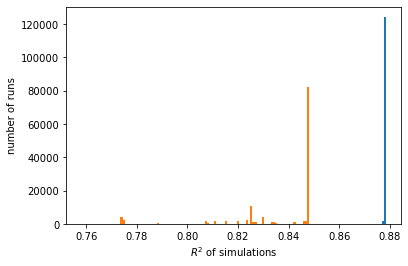

In [30]:
#plot histogram
bins =100

plt.hist(best_individual_df[best_individual_df.binned == 'False'].ga_error, bins=bins)
plt.hist(best_individual_df[best_individual_df.binned == 'False'].r_squared, bins= bins)
plt.xlabel('$R^{2}$ of simulations')
plt.ylabel('number of runs')


Text(0, 0.5, 'number of runs')

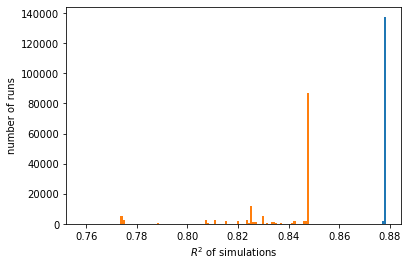

In [31]:
plt.hist(best_individual_df[best_individual_df.binned == 'all'].ga_error, bins=bins)
plt.hist(best_individual_df[best_individual_df.binned == 'all'].r_squared, bins= bins)
plt.xlabel('$R^{2}$ of simulations')
plt.ylabel('number of runs')

Text(0, 0.5, 'number of runs')

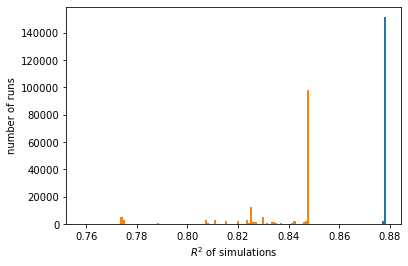

In [32]:
plt.hist(best_individual_df[best_individual_df.binned == 'before'].ga_error, bins=bins)
plt.hist(best_individual_df[best_individual_df.binned == 'before'].r_squared, bins= bins)
plt.xlabel('$R^{2}$ of simulations')
plt.ylabel('number of runs')

## Plot evaluation of error during runs

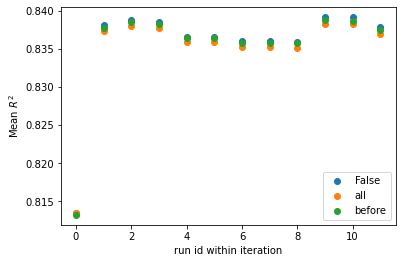

In [10]:
groups = error_per_runid_config.groupby(['binned'])

fig, ax = plt.subplots()
for name, group in groups:
    ax.scatter(group['run_id'], group['r_squared_mean'], label=name)
ax.set_xlabel('run id within iteration')
ax.set_ylabel('Mean $R^{2}$')
plt.legend()
plt.show()

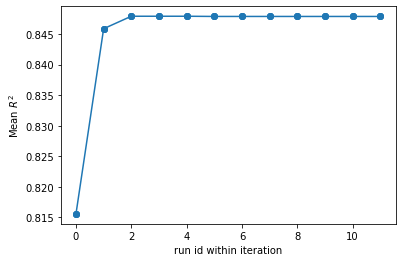

In [34]:
fig, ax = plt.subplots()
ax.scatter(error_per_runid_config['run_id'], error_per_runid_config['r_squared_mean'])
ax.errorbar(error_per_runid_config['run_id'], error_per_runid_config['r_squared_mean'],
            yerr = error_per_runid_config['r_squared_std'])
ax.set_xlabel('run id within iteration')
ax.set_ylabel('Mean $R^{2}$')
plt.show()

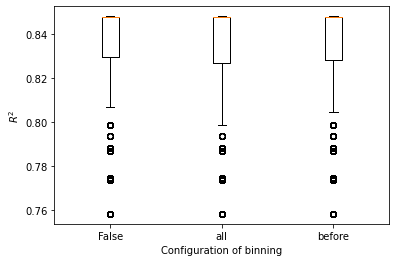

In [11]:
groups = best_individual_df.groupby(['binned'])
import numpy as np

fig, ax = plt.subplots()
i=0
for name, group in groups:
    ax.boxplot(group['r_squared'], positions=[i], vert=True)
#     last_run_errors = group[group['run_id']==11]['r_squared']
#     ax.scatter([i + np.random.uniform(-0.4, 0.4) for j in range(len(last_run_errors))], last_run_errors)
    i+= 1

ax.set_xlabel('Configuration of binning')
ax.set_ylabel('$R^{2}$')
ax.set_xticklabels(groups.groups.keys())
plt.show()

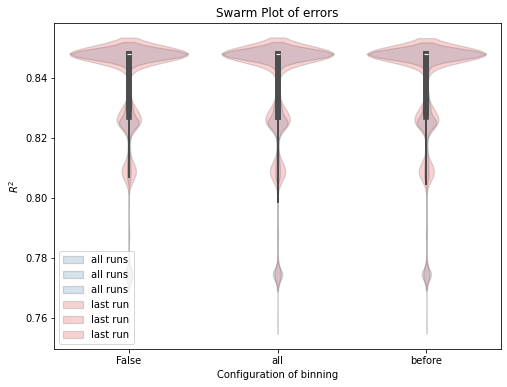

In [17]:
# Create a swarm plot
plt.figure(figsize=(8, 6))
sns.violinplot(x='binned', y='r_squared', data=best_individual_df, alpha =0.2, label = 'all runs')
sns.violinplot(x='binned', y='r_squared', data=best_individual_df[best_individual_df['run_id']==11], 
               alpha=0.2,color ='red', label = 'last run')
# sns.violinplot(x='binned', y='r_squared', data=best_individual_df[best_individual_df['run_id']==1], 
#                alpha=0.2,color ='blue', label = 'first run')
# sns.violinplot(x='binned', y='r_squared', data=best_individual_df, 
#                alpha=0.2,color ='red', label = 'ga_error')


# Set plot title and labels
plt.title('Swarm Plot of errors')
plt.xlabel('Configuration of binning')
plt.ylabel('$R^{2}$')
plt.legend()

# Show plot
plt.show()


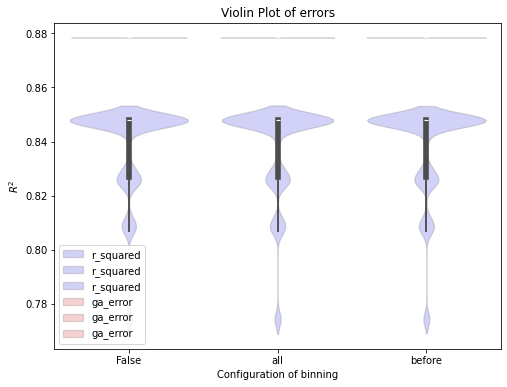

In [13]:
# Create a swarm plot
plt.figure(figsize=(8, 6))
sns.violinplot(x='binned', y='r_squared', data=best_individual_df[best_individual_df['run_id']==11],
              alpha=0.2,color ='blue', label = 'r_squared')
sns.violinplot(x='binned', y='ga_error', data=best_individual_df[best_individual_df['run_id']==11], 
               alpha=0.2,color ='red', label = 'ga_error')

# Set plot title and labels
plt.title('Violin Plot of errors')
plt.xlabel('Configuration of binning')
plt.ylabel('$R^{2}$')

# Show plot
plt.legend()
plt.show()
